<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 170 &middot; Capstone 11 &middot; Pearson Correlation</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Do Study Hours Track Exam Scores?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:800px;line-height:1.6">The first capstone about a relationship rather than a difference. It is also the first where a single data point materially changes the headline number, which is why the scatterplot comes before the correlation, not after it.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, DARK, BL, RD, GR, MUT = "#b45309", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-study-hours-and-scores.xlsx"
try: raw = pd.read_excel("../../data/" + fn, sheet_name="students")
except FileNotFoundError: raw = pd.read_excel(BASE + fn, sheet_name="students")
print("loaded", raw.shape[0], "rows")
raw.head()

loaded 94 rows


,student_id,study_hours_week,exam_score
0,S3000,7.5,76.0
1,S3001,10.3,88.0
2,S3002,15.5,75.0
3,S3003,17.3,83.0
4,S3004,9.1,73.0


## Step 1 &middot; Goal and hypotheses
A survey recorded each student's self-reported weekly study hours alongside their final exam score. The question is how strongly the two move together.

Correlation asks about the **strength and direction of a relationship**, not about a difference between groups.
- **H&#8320; (null):** the true correlation is zero; study hours and exam score are unrelated.
- **H&#8321; (alternative):** the correlation is not zero.
- **&#945; = 0.05.**

Note what a correlation does **not** claim: it says nothing about which variable causes which, or whether either causes the other at all. Step 10 takes that seriously.

## Step 2 &middot; Know the data types
Both variables are **continuous**: hours per week and a score out of 100. Two continuous variables measured on the same people is the setting for **Pearson's correlation**, provided the relationship is roughly linear.

In [2]:
print(raw.dtypes)
print("\ntwo continuous variables on the same students -> Pearson's r (if linear)")

student_id              str
study_hours_week    float64
exam_score          float64
dtype: object

two continuous variables on the same students -> Pearson's r (if linear)


## Step 3 &middot; Prepare and clean

In [3]:
before = len(raw)
df = raw.drop_duplicates(); a_dup = len(df)
df = df.dropna(subset=["study_hours_week","exam_score"]); a_na = len(df)
bad = df[df.study_hours_week <= 0]
df = df[df.study_hours_week > 0].copy()
print(f"start {before}  ->  dedup {a_dup} (-{before-a_dup})  ->  dropna {a_na} (-{a_dup-a_na})")
print("impossible study hours removed:", sorted(bad.study_hours_week.tolist()))
print(f"clean analysis sample: n = {len(df)}")
print(df[["study_hours_week","exam_score"]].describe().round(2).to_string())

start 94  ->  dedup 93 (-1)  ->  dropna 91 (-2)
impossible study hours removed: [-2.0]
clean analysis sample: n = 90
       study_hours_week  exam_score
count             90.00       90.00
mean              11.14       74.14
std                3.46       10.72
min                1.90       38.00
25%                8.57       67.25
50%               10.85       75.00
75%               13.38       80.75
max               21.50       99.00


## Step 4 &middot; Look at the scatterplot BEFORE computing anything
This is the step people skip, and it is the one that matters most for correlation. A single number cannot tell you whether the relationship is linear, whether it curves, or whether one unusual student is steering the whole result.

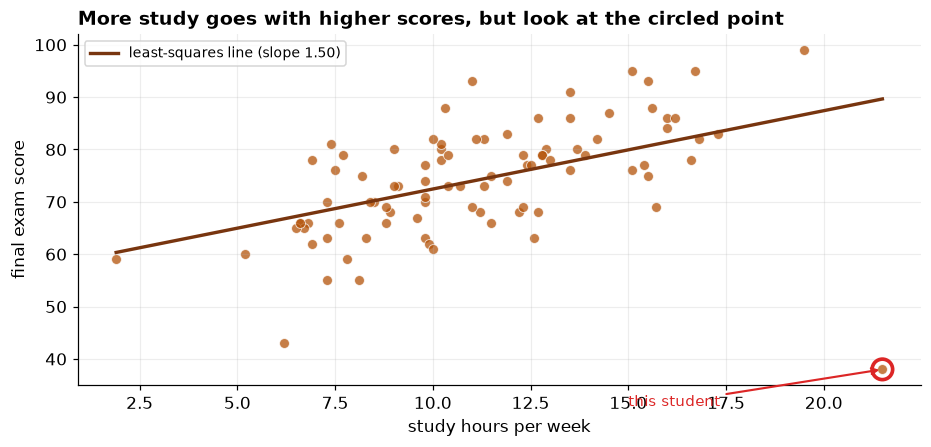

In [4]:
x = df.study_hours_week.values; y = df.exam_score.values
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.scatter(x, y, s=42, alpha=0.75, color=GOLD, edgecolor="white", linewidth=0.6)
b, a_ = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, a_ + b*xs, color=DARK, lw=2.2, label=f"least-squares line (slope {b:.2f})")
# flag the most unusual point
resid = y - (a_ + b*x); k = np.argmax(np.abs(resid))
ax.scatter([x[k]], [y[k]], s=180, facecolor="none", edgecolor=RD, linewidth=2.4, zorder=5)
ax.annotate("this student", xy=(x[k], y[k]), xytext=(x[k]-6.5, y[k]-7), color=RD, fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color=RD, lw=1.4))
ax.set_xlabel("study hours per week"); ax.set_ylabel("final exam score")
ax.set_title("More study goes with higher scores, but look at the circled point"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**What the scatter shows.** The cloud slopes upward: students who study more tend to score higher, and the relationship looks broadly linear rather than curved, so Pearson's correlation is a reasonable summary. But one student sits far off the pattern, studying more than almost anyone and scoring near the bottom. That point is not a data error, it is a real student, and Step 7 measures how much it is pulling the answer around.

## Step 5 &middot; Name the design
One sample of students, two continuous variables measured on each, no groups and no intervention. This is an **observational, cross-sectional correlational design**, which is the weakest design in the book for causal claims and the most common one in practice.

## Step 6 &middot; Check the assumptions
Pearson's r assumes the relationship is **linear**, that there are no wildly influential points distorting it, and, for the p-value and confidence interval, that the two variables are roughly **bivariate normal**.

In [5]:
sw_x = stats.shapiro(x); sw_y = stats.shapiro(y)
print(f"Shapiro-Wilk on study hours: W = {sw_x.statistic:.3f}, p = {sw_x.pvalue:.3f}")
print(f"Shapiro-Wilk on exam score : W = {sw_y.statistic:.3f}, p = {sw_y.pvalue:.3f}")
print("\nlinearity: judged from the scatterplot above (no obvious curve)")
print("influence: one point stands out; quantified in the next step")

Shapiro-Wilk on study hours: W = 0.983, p = 0.282
Shapiro-Wilk on exam score : W = 0.978, p = 0.139

linearity: judged from the scatterplot above (no obvious curve)
influence: one point stands out; quantified in the next step


## Step 7 &middot; Run the test, then test the result's stability
We compute r with a confidence interval, then do something every correlation analysis should do and most do not: **refit without the influential point** and see how much the answer moves.

In [6]:
r, p = stats.pearsonr(x, y)
n = len(df)
z = np.arctanh(r); se = 1/np.sqrt(n-3)
lo, hi = np.tanh(z-1.96*se), np.tanh(z+1.96*se)
print(f"n = {n}")
print(f"Pearson r = {r:.3f}   p = {p:.2e}")
print(f"95% CI for r: [{lo:.3f}, {hi:.3f}]")
print(f"r-squared = {r**2:.3f}   -> study hours account for about {r**2*100:.0f}% of the variation in scores")

n = 90
Pearson r = 0.483   p = 1.40e-06
95% CI for r: [0.307, 0.628]
r-squared = 0.234   -> study hours account for about 23% of the variation in scores


In [7]:
# how much does that one student matter?
keep = df.student_id != "S9999"
r_wo, p_wo = stats.pearsonr(df[keep].study_hours_week, df[keep].exam_score)
rho, p_rho = stats.spearmanr(x, y)
print(f"Pearson r  WITH  the influential student : {r:.3f}")
print(f"Pearson r WITHOUT the influential student : {r_wo:.3f}   (moves {r_wo-r:+.3f})")
print(f"Spearman rho (rank-based, WITH the point) : {rho:.3f}")
print(f"\none student out of {n} shifts r by {abs(r_wo-r):.3f}, from '{'moderate' if r<0.5 else 'strong'}' to '{'moderate' if r_wo<0.5 else 'strong'}'.")

Pearson r  WITH  the influential student : 0.483
Pearson r WITHOUT the influential student : 0.676   (moves +0.193)
Spearman rho (rank-based, WITH the point) : 0.613

one student out of 90 shifts r by 0.193, from 'moderate' to 'strong'.


**This is the finding behind the finding.** With every student included, r is **0.483**. Remove one student, and r jumps to **0.676**. A single observation out of ninety moves the correlation by nearly **0.2**, which is the difference between describing the relationship as moderate and describing it as strong. Notice too that **Spearman's rank correlation is 0.613**, much closer to the without-the-point value, because ranks care that the student scored low, not how far below the line they landed.

None of this means the point should be deleted. It is a real student, not a typo. It means the honest report gives r **with** the point and **discloses** how much rests on it.

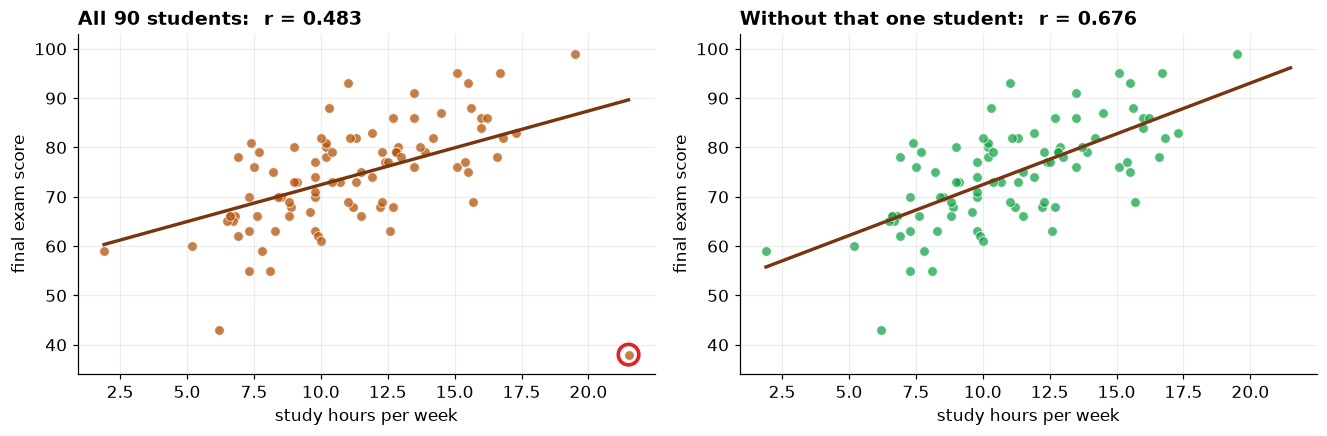

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12.2, 4.1))
for a__, subset, ttl, col in [
    (ax[0], df, f"All {n} students:  r = {r:.3f}", GOLD),
    (ax[1], df[keep], f"Without that one student:  r = {r_wo:.3f}", GR)]:
    xx = subset.study_hours_week.values; yy = subset.exam_score.values
    a__.scatter(xx, yy, s=40, alpha=0.75, color=col, edgecolor="white", linewidth=0.6)
    bb, aa = np.polyfit(xx, yy, 1); xs2 = np.linspace(x.min(), x.max(), 100)
    a__.plot(xs2, aa + bb*xs2, color=DARK, lw=2.2)
    a__.set_xlabel("study hours per week"); a__.set_ylabel("final exam score")
    a__.set_title(ttl); a__.set_ylim(y.min()-4, y.max()+4)
ax[0].scatter([x[k]], [y[k]], s=180, facecolor="none", edgecolor=RD, linewidth=2.4, zorder=5)
plt.tight_layout(); plt.show()

**The same dataset, one point apart.** The left panel keeps every student and the right panel drops one. The slope visibly steepens and the cloud tightens around it. Any reader shown only one of these panels would come away with a different sense of how much studying matters.

## Step 8 &middot; Where the correlation comes from: covariance
Pearson's r arrived from a library call. It is worth opening it up once, because r is not a primitive quantity. It is **covariance with the units divided out**, and seeing that explains both why r has no units and why it cannot leave the range from &#8722;1 to +1.

In [9]:
cov = np.cov(x, y, ddof=1)[0, 1]
sx, sy = x.std(ddof=1), y.std(ddof=1)
print(f"covariance(hours, score) = {cov:8.3f}   units: hours x points  <- not interpretable")
print(f"SD of study hours        = {sx:8.3f}   hours")
print(f"SD of exam score         = {sy:8.3f}   points\n")
print(f"r = covariance / (SD_x * SD_y) = {cov:.3f} / ({sx:.3f} x {sy:.3f}) = {cov/(sx*sy):.3f}")
print(f"scipy's Pearson r                                        = {r:.3f}\n")

# Covariance depends on the units; r does not. Rescale and watch.
print(f"{'variable coding':34s} {'covariance':>12s} {'r':>8s}")
print("-"*56)
for lab, xs_, ys_ in [("hours, points (as recorded)", x, y),
                      ("MINUTES, points", x*60, y),
                      ("hours, score out of 1000", x, y*10),
                      ("MINUTES, score out of 1000", x*60, y*10)]:
    print(f"{lab:34s} {np.cov(xs_, ys_, ddof=1)[0,1]:12.1f} {stats.pearsonr(xs_, ys_).statistic:8.3f}")

covariance(hours, score) =   17.939   units: hours x points  <- not interpretable
SD of study hours        =    3.463   hours
SD of exam score         =   10.719   points

r = covariance / (SD_x * SD_y) = 17.939 / (3.463 x 10.719) = 0.483
scipy's Pearson r                                        = 0.483

variable coding                      covariance        r
--------------------------------------------------------
hours, points (as recorded)                17.9    0.483
MINUTES, points                          1076.4    0.483
hours, score out of 1000                  179.4    0.483
MINUTES, score out of 1000              10763.7    0.483


**Covariance measures the same thing r does, in the wrong units.** It is positive here, which tells us hours and scores move together, and that is all it tells us: the value 17.9 is in "hours times points", a unit nobody has an intuition for. Switch study time to minutes and the covariance is multiplied by 60. Score out of 1000 instead of 100 and it multiplies again. The relationship never changed; only the bookkeeping did.

**Dividing by both standard deviations strips the units out.** That is the whole of Pearson's formula, and it is why r stays fixed at 0.483 through all four codings in the table while the covariance ranges over four orders of magnitude. It is also why r is capped at 1: the covariance can never exceed the product of the two standard deviations. Chapter 89 develops this; the point of repeating it here is that **the correlation you report is a rescaled covariance**, and knowing that is what makes the coefficient interpretable rather than magic.

## Step 9 &middot; Intervals for the things we are about to quote

In [10]:
# A percentile bootstrap: resample the data with replacement, recompute, repeat.
# Chapter 73 introduced this; it is how we get an interval when no formula exists.
def boot_ci(data, stat, B=10000, seed=11, ci=95):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    reps = np.array([stat(rng.choice(data, size=len(data), replace=True)) for _ in range(B)])
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_pairs(a, b, stat, B=10000, seed=11, ci=95):
    """Bootstrap for two paired/related arrays: resample ROW indices together."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    idx = np.arange(len(a))
    reps = np.array([stat(a[i], b[i]) for i in
                     (rng.choice(idx, size=len(idx), replace=True) for _ in range(B))])
    reps = reps[np.isfinite(reps)]
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_groups(groups, stat, B=10000, seed=11, ci=95):
    """Bootstrap for k independent groups: resample within each group."""
    rng = np.random.default_rng(seed)
    groups = [np.asarray(g) for g in groups]
    reps = []
    for _ in range(B):
        rs = [rng.choice(g, size=len(g), replace=True) for g in groups]
        v = stat(rs)
        if np.isfinite(v):
            reps.append(v)
    reps = np.array(reps)
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

print(f"Pearson r        {r:.3f}   95% CI [{lo:.3f}, {hi:.3f}]   (Fisher z, the usual formula)")
rb_lo, rb_hi, _ = boot_ci_pairs(x, y, lambda a, b: stats.pearsonr(a, b).statistic)
print(f"Pearson r        {r:.3f}   95% CI [{rb_lo:.3f}, {rb_hi:.3f}]   (bootstrap, no assumptions)")
r2_lo, r2_hi, _ = boot_ci_pairs(x, y, lambda a, b: stats.pearsonr(a, b).statistic**2)
print(f"r-squared        {r**2:.3f}   95% CI [{r2_lo:.3f}, {r2_hi:.3f}]   (bootstrap)")
rho_lo, rho_hi, _ = boot_ci_pairs(x, y, lambda a, b: stats.spearmanr(a, b).statistic)
print(f"Spearman rho     {rho:.3f}   95% CI [{rho_lo:.3f}, {rho_hi:.3f}]")
xk = df[keep].study_hours_week.values; yk = df[keep].exam_score.values
rwo_lo, rwo_hi, _ = boot_ci_pairs(xk, yk, lambda a, b: stats.pearsonr(a, b).statistic)
print(f"r without S9999  {r_wo:.3f}   95% CI [{rwo_lo:.3f}, {rwo_hi:.3f}]\n")
print("the two r intervals overlap heavily, which is the honest way to say that")
print("removing one student shifts the estimate without producing a different finding")

Pearson r        0.483   95% CI [0.307, 0.628]   (Fisher z, the usual formula)


Pearson r        0.483   95% CI [0.126, 0.750]   (bootstrap, no assumptions)


r-squared        0.234   95% CI [0.016, 0.563]   (bootstrap)


Spearman rho     0.613   95% CI [0.433, 0.754]


r without S9999  0.676   95% CI [0.555, 0.773]

the two r intervals overlap heavily, which is the honest way to say that
removing one student shifts the estimate without producing a different finding


**Two intervals for r, and they disagree.** The Fisher z formula gives 0.31 to 0.63. The bootstrap, which assumes nothing, gives a noticeably wider range. That gap is not a bug; it is the influential student showing up again. Fisher's interval is derived assuming the pair of variables is bivariate normal with no high-leverage points, and this sample has one. **When a parametric interval and a bootstrap disagree, the bootstrap is usually telling you an assumption is not holding**, and it is the one to report.

**The share of variation, with its uncertainty.** Study hours account for 23 percent of the variation in scores, and the bootstrap interval on r-squared is very wide indeed, running from a few percent to over half. That width is the honest summary of what 90 students with one discrepant observation can establish. "About a quarter, and do not lean on it" is a fair reading; "23.4 percent" is not.

The influence analysis reads better with intervals too. Dropping the one discrepant student moves r from 0.48 to 0.68, which sounds dramatic, but the two intervals overlap. The estimate is sensitive to that observation without the two versions telling genuinely different stories, which is a more measured statement than either point estimate alone.

## Step 10 &middot; Interpret in plain language
Study hours and exam scores are **positively and significantly related** (r = 0.48, p &lt; 0.001, 95% CI 0.31 to 0.63). Squaring r, study hours account for roughly **23%** of the variation in exam scores, which leaves **about three quarters of it unexplained** by hours alone. That is the number worth quoting to a student: studying more is associated with scoring better, and it is nowhere near the whole story.

## Step 11 &middot; What r does not tell you
An r of 0.48 is a statement about **co-movement**, and three different worlds would produce it.

In [11]:
print("Three explanations consistent with r = 0.48:\n")
print("  1. studying causes higher scores")
print("  2. reverse: students who find the material easy (and score well) enjoy it and study more")
print("  3. a third variable drives both, e.g. prior preparation, motivation, or free time")
print("\nthis design cannot separate them: no randomization, no time ordering, no control for confounders.")

Three explanations consistent with r = 0.48:

  1. studying causes higher scores
  2. reverse: students who find the material easy (and score well) enjoy it and study more
  3. a third variable drives both, e.g. prior preparation, motivation, or free time

this design cannot separate them: no randomization, no time ordering, no control for confounders.


## Step 12 &middot; Ethics, bias, and limits
- **Correlation is not causation, and here the reverse direction is genuinely plausible.** Students who already understand the material may both study more comfortably and score higher. Nothing in a cross-sectional survey can order the two.
- **Self-reported hours are optimistic.** People overestimate study time, and the overestimate is unlikely to be uniform: weaker students may over-report more, which would flatten the observed relationship. The measurement error is in the predictor, and it biases r toward zero.
- **One student is carrying a lot of the answer.** Report r with the influential point included, but disclose its effect. Silently deleting it to get a stronger result would be data manipulation; failing to mention it would be a different kind of omission.
- **Do not turn this into advice.** "Study 5 more hours to gain 10 points" reads a causal slope off a correlational design. The honest version is that more study is associated with better scores, on average, with wide variation between individuals.
- **Restricted range matters.** These are students who enrolled and sat the exam. The relationship among a wider population, including those who dropped out, could differ.

---
**From analysis to report.** The notebook carries the evidence: the scatterplot, the assumption checks, r with its interval, the influence analysis, and the rank-based comparison. The written reports turn it into something a course leader can use and a technical account a fellow statistician can audit. Automate the evidence; author the argument.